## CIFAR10 Dataset Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    VotingClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GridSearchCV, 
    cross_val_score,
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay

)

import warnings
warnings.filterwarnings("ignore")

## Load CIFAR-10 Dataset

In [2]:
# Load dataset from OpenML
cifar = fetch_openml('CIFAR_10_small')

# Features and labels
X = cifar.data
y = cifar.target

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

Dataset Shape: (20000, 3072)
Labels Shape: (20000,)


## Split Dataset

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(16000, 3072)
(4000, 3072)


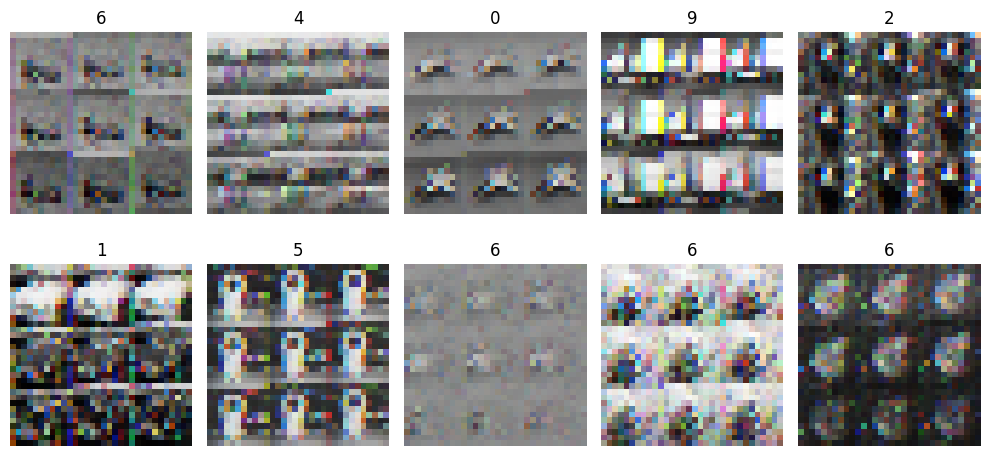

In [14]:
plt.figure(figsize=(10, 5))

for i in range(10):
    image = X_train.iloc[i].values.reshape(32, 32, 3)
    plt.subplot(2, 5, i + 1)
    plt.imshow(image.astype(np.uint8), cmap="gray")
    plt.title(y_train.iloc[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Class Names
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [15]:
# Feature Scaling
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [17]:
# PCA
pca=PCA(n_components=200)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)

print(X_train_pca.shape)
print(X_test_pca.shape)

(16000, 200)
(4000, 200)


In [18]:
# Explained Variance
explained_variance=np.sum(pca.explained_variance_ratio_)

print("Explained Variance:", explained_variance)

Explained Variance: 0.9455644202959292


In [ ]:
# PCA Variance Graph
cumulative_variance=np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)
 
plt.show()

## Logistic Regression (Baseline Model)

In [ ]:
log_model=LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_pca, y_train)

log_pred=log_model.predict(X_test_pca)

# Evaluate Logistic Regression
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))

print("Logistic Regression Precision:", precision_score(y_test, log_pred, average='weighted'))

print("Logistic Regression Recall:", recall_score(y_test, log_pred, average='weighted'))

print("Logistic Regression F1 Score:", f1_score(y_test, log_pred, average='weighted'))

## Random Forest

In [ ]:
rf_model=RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_pca, y_train)

rf_pred=rf_model.predict(X_test_pca)

#Evaluate Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


## Extra Trees

In [ ]:
extra_model=ExtraTreesClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(X_train_pca, y_train)

extra_pred=extra_model.predict(X_test_pca)

# Evaluate Extra Trees
print("Extra Trees Accuracy:", accuracy_score(y_test, extra_pred))

## Gradient Boosting
gb_model=GradientBoostingClassifier(
    
)